In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
from pathlib import Path

warnings.filterwarnings("ignore")

# ---------- 冻结参数（与 config/analysis_parameters_v1.yaml 一致）----------
SEED        = 2026      # 随机种子（任务书 4.6：seed=2026）
N_PC_TOTAL  = 50        # pseudobulk PCA 保留的总 PC 数
N_PC_AXIS   = 10        # 衰老方向使用的 PC 数（用户 2026-09-15 指定）
                        #   依据 08_DE.ipynb 的 pca_variance_ratio 碎石图：
                        #   PC1-10 累计解释方差 60.4%（PC1 19.0% / PC2 12.9% / PC3 6.5%），
                        #   拐点之后单 PC 贡献降到约 1% 量级 -> 取前 10 个 PC 作衰老方向。
                        #   PC 数敏感性见 Cell 6(a)，同时报告 PC20 / PC30 供对照。
AGG_MODE    = "mean"    # 样本坐标口径 = 均值（任务书 4.3）
                        #   pseudobulk PCA 下每 mouse x tissue x cell_type 恰 1 条坐标，
                        #   故"均值"即该条坐标本身（不存在 10% 截尾均值选项）。
                        #   若将来改用"细胞级 PCA 坐标再按小鼠汇总"，同一 AGG_MODE
                        #   必须同时应用于 mu 与样本坐标；两种表示的结果不可混用。
MIN_YOUNG   = 2         # 节点进入方向分析所需的最少 young 独立小鼠数
MIN_OLD     = 2         # 同上，old
SIG_ALPHA   = 0.05      # 年龄趋势显著性阈值
LOW_CELLS   = 30        # pseudobulk 细胞数低可信阈值（任务书第7周）

# ---------- 路径 ----------
BASE   = Path("..")
AXIS   = BASE / "results" / "aging_axis"
FIGDIR = BASE / "figures" / "main"
PB_H5AD = BASE / "data_processed" / "pseudobulk.h5ad"
for d in (AXIS, FIGDIR):
    d.mkdir(parents=True, exist_ok=True)

# ---------- 复用 src/aging_axis.py ----------
sys.path.insert(0, str((BASE / "src").resolve()))
import aging_axis as aa
print("aging_axis 模块:", aa.__file__)

# 图中文字一律用英文（避免字体缺失）；此处仅设置中文字体回退，负号正常显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"SEED={SEED} | PC1-{N_PC_AXIS} 用于衰老方向 | 样本坐标口径 AGG_MODE={AGG_MODE} | "
      f"最少小鼠 young/old >= {MIN_YOUNG}/{MIN_OLD}")
print(f"输出目录: {AXIS.resolve()}")


aging_axis 模块: D:\Desktop\--main\src\aging_axis.py
SEED=2026 | PC1-10 用于衰老方向 | 样本坐标口径 AGG_MODE=mean | 最少小鼠 young/old >= 2/2
输出目录: D:\Desktop\--main\results\aging_axis


In [2]:
import scanpy as sc
import anndata as ad

adata_pb = ad.read_h5ad(PB_H5AD)
adata_pb.layers["counts"] = adata_pb.X.copy()          # 保留原始 counts
print(f"pseudobulk 载入: {adata_pb.shape}  (行 = 独立样本 mouse x tissue x cell_type)")

# ---- 与 08_DE.ipynb Cell 2 完全一致的口径（实现见 src/aging_axis.pseudobulk_pca）----
aa.pseudobulk_pca(adata_pb, n_comps=N_PC_TOTAL, seed=SEED)

vr = np.asarray(adata_pb.uns["pca"]["variance_ratio"], float)
print(f"PC1-{N_PC_TOTAL} 累计解释方差 {vr.sum() * 100:.1f}%  "
      f"(PC1 {vr[0] * 100:.1f}%, PC2 {vr[1] * 100:.1f}%, PC3 {vr[2] * 100:.1f}%)")
print("obsm['X_pca']:", adata_pb.obsm["X_pca"].shape)

# ---- 持久化：第11/12周可直接复用，避免再出现"输入文件缺失" ----
pb_pca_path = BASE / "data_processed" / "pseudobulk_pca.h5ad"
adata_pb.write_h5ad(pb_pca_path)
print("已保存 pseudobulk + PCA:", pb_pca_path)

# ---- 展成样本级数据表 ----
ml = aa.mouse_level_table(adata_pb, n_pc=N_PC_TOTAL)
PC_COLS = aa.pc_columns(N_PC_AXIS)
print(f"\n样本表: {ml.shape} | 节点 {ml['node'].nunique()} 个 | 独立小鼠 "
      f"{ml['mouse.id'].nunique()} 只")
print(ml[["sample", "node", "mouse.id", "age_months", "age_group",
          "psbulk_cells", "PC1", "PC2"]].head(6).to_string(index=False))

# ---- 样本坐标口径核查（任务书 4.3：使用均值）----
# pseudobulk PCA 下每个 mouse x tissue x cell_type 恰有 1 条样本，
# 因此"样本坐标 = 均值"恒等成立（不存在跨细胞求平均这一步）。
_grp = ml.groupby(["node", "mouse.id"])
_dup_max = int(_grp.size().max())
assert _dup_max == 1, "同一节点内同一小鼠有多条样本，需先按 AGG_MODE 汇总"
_orig = ml.set_index(["node", "mouse.id"])[PC_COLS].sort_index()
_mean = _grp[PC_COLS].mean().sort_index()
_max_dev = float((_mean - _orig).abs().to_numpy().max())
print(f"\n样本坐标口径 AGG_MODE='{AGG_MODE}'；每 (node, mouse) 最大样本数 = {_dup_max}"
      f" -> 均值即该条坐标本身；均值与原始坐标最大绝对偏差 = {_max_dev:.2e}")


pseudobulk 载入: (119, 20138)  (行 = 独立样本 mouse x tissue x cell_type)


PC1-50 累计解释方差 89.4%  (PC1 19.0%, PC2 12.9%, PC3 6.5%)
obsm['X_pca']: (119, 50)
已保存 pseudobulk + PCA: ..\data_processed\pseudobulk_pca.h5ad

样本表: (119, 65) | 节点 8 个 | 独立小鼠 22 只
              sample                    node mouse.id  age_months age_group  psbulk_cells        PC1        PC2
       1-M-62_Kidney        Kidney__lymphoid   1-M-62           1     young          18.0   6.560895 -12.730366
        1-M-62_Liver         Liver__lymphoid   1-M-62           1     young           3.0  -6.746166 -28.885330
         1-M-62_Lung          Lung__lymphoid   1-M-62           1     young         222.0 -14.320601 -26.540771
1-M-62_spleen/marrow spleen/marrow__lymphoid   1-M-62           1     young         137.0 -28.777027  22.892467
       1-M-63_Kidney        Kidney__lymphoid   1-M-63           1     young          18.0   5.384305 -14.786695
        1-M-63_Liver         Liver__lymphoid   1-M-63           1     young         256.0  -8.181390 -22.026037

样本坐标口径 AGG_MODE='mean'；每 (node, mouse) 

In [3]:
# ===================== Cell 3：节点覆盖审计与技术混杂检查 =====================
cov = aa.node_coverage(ml)
print("节点覆盖（独立小鼠数）:")
print(cov.to_string())

VALID_NODES, EXCLUDED = aa.select_valid_nodes(cov, MIN_YOUNG, MIN_OLD)
print(f"\n进入衰老方向分析的节点 ({len(VALID_NODES)}/{len(cov)}):")
for nd in VALID_NODES:
    print(f"  ok  {nd:38s} young={int(cov.loc[nd, 'young'])}, "
          f"old={int(cov.loc[nd, 'old'])}, n_mice={int(cov.loc[nd, 'n_mice'])}")
for nd, why in EXCLUDED.items():
    print(f"  [排除] {nd}: {why}")

# ---- 技术混杂检查（任务书风险矩阵：年龄与技术批次混杂）----
if "method" in ml.columns:
    ct = pd.crosstab(ml["age_group"], ml["method"].astype(str))
    print("\nage_group x method:")
    print(ct.to_string())
    n_method = int(ml["method"].astype(str).nunique())
    if n_method == 1:
        print(f"-> 技术平台数 = {n_method}（{ml['method'].astype(str).unique()[0]}）："
              f"各年龄层共用同一平台，**不存在年龄 x 批次混杂**")
    else:
        print(f"-> 技术平台数 = {n_method}：需在方向解释中说明潜在批次影响")

# ---- 样本量提示：pseudobulk 细胞数过低的样本标记为低可信 ----
low = ml[ml["psbulk_cells"] < LOW_CELLS].copy()
print(f"\npsbulk_cells < {LOW_CELLS} 的样本: {len(low)}/{len(ml)}  "
      f"({len(low) / len(ml) * 100:.1f}%)")
if len(low):
    print(low.groupby("node").size().to_string())
low[["sample", "node", "mouse.id", "age_months", "age_group", "psbulk_cells"]] \
    .sort_values("psbulk_cells") \
    .to_csv(AXIS / "low_cell_samples.tsv", sep="\t", index=False)
print("已保存 -> results/aging_axis/low_cell_samples.tsv")

# ---- 每节点分析用样本表 ----
valid_df = ml[ml["node"].isin(VALID_NODES)].copy()
print(f"\n用于方向分析的样本数: {len(valid_df)}/{len(ml)}")


节点覆盖（独立小鼠数）:
age_group                          young  middle  old  n_mice  n_samples
node                                                                    
Kidney__lymphoid                       5       5    6      16         16
Kidney__myeloid/macrophage             5       5    6      16         16
Liver__lymphoid                        2       2    4       8          8
Liver__myeloid/macrophage              3       2    4       9          9
Lung__lymphoid                         6       6    4      16         16
Lung__myeloid/macrophage               6       6    4      16         16
spleen/marrow__lymphoid                5       6    8      19         19
spleen/marrow__myeloid/macrophage      5       6    8      19         19

进入衰老方向分析的节点 (8/8):
  ok  Kidney__lymphoid                       young=5, old=6, n_mice=16
  ok  Kidney__myeloid/macrophage             young=5, old=6, n_mice=16
  ok  Liver__lymphoid                        young=2, old=4, n_mice=8
  ok  Liver__myeloid/macr

In [4]:
# ===================== Cell 4：节点衰老方向 d = mu(old) - mu(young) =====================
directions, dir_rows = {}, []
for nd in VALID_NODES:
    sub = ml[ml["node"] == nd]
    d, mu_y, mu_o, n_y, n_o = aa.aging_direction(sub, PC_COLS)
    directions[nd] = d
    row = {"node": nd, "n_mice_young": n_y, "n_mice_old": n_o,
           "n_mice_total": len(sub), "n_pc": len(PC_COLS),
           "direction_norm": float(np.linalg.norm(d))}
    row.update({c: float(d[i]) for i, c in enumerate(PC_COLS)})
    dir_rows.append(row)

dir_df = pd.DataFrame(dir_rows).set_index("node")
dir_df.to_csv(AXIS / "aging_directions.csv")
print("各节点衰老方向（行 = 节点，列 = PC1-PC%d）:" % len(PC_COLS))
print(dir_df[["n_mice_young", "n_mice_old", "n_mice_total", "direction_norm"]].to_string())
print("\n方向向量前 5 个 PC 分量:")
print(dir_df[[f"PC{i}" for i in range(1, 6)]].round(3).to_string())

assert (dir_df["direction_norm"] > 0).all(), "存在零方向"
assert (dir_df["n_mice_young"] >= MIN_YOUNG).all() and (dir_df["n_mice_old"] >= MIN_OLD).all()
print("\n完整性检查通过：所有节点 ||d|| > 0，且 young/old 小鼠数达标")
print("已保存 -> results/aging_axis/aging_directions.csv")


各节点衰老方向（行 = 节点，列 = PC1-PC10）:
                                   n_mice_young  n_mice_old  n_mice_total  direction_norm
node                                                                                     
Kidney__lymphoid                              5           6            16       21.933494
Kidney__myeloid/macrophage                    5           6            16       22.891175
Liver__lymphoid                               2           4             8       61.539440
Liver__myeloid/macrophage                     3           4             9       39.711251
Lung__lymphoid                                6           4            16       15.648507
Lung__myeloid/macrophage                      6           4            16       15.774435
spleen/marrow__lymphoid                       5           8            19       13.390279
spleen/marrow__myeloid/macrophage             5           8            19       18.177000

方向向量前 5 个 PC 分量:
                                      PC1    PC2    

In [5]:
# ===================== Cell 5：每只小鼠的投影得分 A(m) 与年龄趋势 =====================
score_rows, node_rows = [], []
for nd in VALID_NODES:
    sub = ml[ml["node"] == nd].copy()
    d, mu_y, _, n_y, n_o = aa.aging_direction(sub, PC_COLS)

    # A(m) = (z_m - mu_young) . d / ||d||；投影对每只小鼠独立计算
    sub["aging_score"] = aa.aging_score(sub, d, mu_y, PC_COLS)
    rho, p = aa.score_age_trend(sub["aging_score"], sub["age_months"])

    keep = ["sample", "mouse.id", "tissue", "major_cell_type", "sex",
            "age_months", "age_group", "psbulk_cells", "node", "aging_score"]
    score_rows.append(sub[keep].assign(spearman_rho=rho, spearman_p=p))
    node_rows.append({"node": nd, "n_mice_young": n_y, "n_mice_old": n_o,
                      "n_mice_total": len(sub), "n_mice_middle":
                      int((sub["age_group"] == "middle").sum()),
                      "direction_norm": float(np.linalg.norm(d)),
                      "spearman_rho": rho, "spearman_p": p,
                      "significant": bool(p < SIG_ALPHA)})

pca_scores = pd.concat(score_rows, ignore_index=True)
pca_scores.to_csv(AXIS / "pca_scores.csv", index=False)
node_summary = pd.DataFrame(node_rows).set_index("node")
node_summary.to_csv(AXIS / "node_summary.tsv", sep="\t")

print("节点汇总（Spearman 相关 = 衰老得分 vs 月龄）：")
print(node_summary.round(4).to_string())
print(f"\n年龄趋势显著节点: {int(node_summary['significant'].sum())}/{len(node_summary)} "
      f"(Spearman p < {SIG_ALPHA})")
print(f"rho 范围: {node_summary['spearman_rho'].min():.3f} ~ "
      f"{node_summary['spearman_rho'].max():.3f}")
print("\n已保存 -> results/aging_axis/pca_scores.csv, node_summary.tsv")


节点汇总（Spearman 相关 = 衰老得分 vs 月龄）：
                                   n_mice_young  n_mice_old  n_mice_total  n_mice_middle  direction_norm  spearman_rho  spearman_p  significant
node                                                                                                                                           
Kidney__lymphoid                              5           6            16              5         21.9335        0.7619      0.0006         True
Kidney__myeloid/macrophage                    5           6            16              5         22.8912        0.7230      0.0016         True
Liver__lymphoid                               2           4             8              2         61.5394        0.8961      0.0026         True
Liver__myeloid/macrophage                     3           4             9              2         39.7113        0.7917      0.0110         True
Lung__lymphoid                                6           4            16              6         15.6485

In [6]:
# ===================== Cell 6：稳健性 —— PC 数 / 基因集 / 最小细胞数 =====================
from scipy import stats

# ---------- (a) PC 数：10 / 20 / 30 ----------
cos_by_k, rho_by_k, pc_rows = {}, {}, []
for k in (10, 20, 30):
    cols_k = aa.pc_columns(k)
    dirs_k, rho_k = {}, {}
    for nd in VALID_NODES:
        sub = ml[ml["node"] == nd]
        d, mu_y, _, _, _ = aa.aging_direction(sub, cols_k)
        dirs_k[nd] = d
        rho_k[nd] = aa.score_age_trend(aa.aging_score(sub, d, mu_y, cols_k),
                                       sub["age_months"])[0]
        pc_rows.append({"n_pc": k, "node": nd, "spearman_rho": rho_k[nd],
                        "direction_norm": float(np.linalg.norm(d))})
    cos_by_k[k], rho_by_k[k] = aa.cosine_matrix(dirs_k, order=VALID_NODES), rho_k

pc_df = pd.DataFrame(pc_rows)
print("(a) PC 数敏感性 —— Spearman rho (衰老得分 vs 月龄):")
print(pc_df.pivot(index="node", columns="n_pc", values="spearman_rho").round(3).to_string())

# 注：短 PC 数的方向恰为长 PC 数方向的**前缀分量**（d_PC10 = d_PC30[:10]），
#     故两者方向余弦恒为 1 —— 这是完整性检查，没有信息量。
#     真正会随 PC 数变化的是【节点两两相似度矩阵】与【得分-年龄相关】，故比较这两者。
base_long = aa.pairwise_cosine_long(cos_by_k[N_PC_AXIS]).set_index(["node_i", "node_j"])["cosine"]
print(f"\n    节点两两相似度矩阵 vs 基线 PC={N_PC_AXIS} 的一致性：")
for k in [x for x in (10, 20, 30) if x != N_PC_AXIS]:
    alt = aa.pairwise_cosine_long(cos_by_k[k]).set_index(["node_i", "node_j"])["cosine"]
    print(f"      PC{k}: r = {np.corrcoef(alt.loc[base_long.index], base_long)[0, 1]:.3f}"
          f"   平均 |Δcosine| = {np.abs(alt.loc[base_long.index] - base_long).mean():.3f}")
spread = np.mean([max(rho_by_k[k][nd] for k in (10, 20, 30))
                  - min(rho_by_k[k][nd] for k in (10, 20, 30)) for nd in VALID_NODES])
print(f"    rho 跨 PC 设置的极差（同节点内）平均 = {spread:.3f}")

# ---------- (b) 基因集：全基因(20138) vs HVG=2000 ----------
# ⚠️ 两个变体的 PCA 基不同（不同特征空间 -> 不同 PC 轴），因此**不能**直接比较
#    方向向量 d 的余弦 —— 跨基比较没有意义。这里改用两个与基无关的量：
#      (i)  同节点、同批小鼠的衰老得分秩相关（得分是标量，跨基可比）
#      (ii) 节点两两相似度矩阵的一致性（矩阵各自在同一基内构造，再比较数值）
try:
    work = adata_pb.copy()
    sc.pp.highly_variable_genes(work, n_top_genes=2000, flavor="seurat")
    work = work[:, work.var["highly_variable"].to_numpy()].copy()
    sc.pp.scale(work, max_value=10)
    sc.tl.pca(work, n_comps=N_PC_TOTAL, svd_solver="arpack", random_state=SEED)
    ml_h = aa.mouse_level_table(work, n_pc=N_PC_TOTAL)

    dirs_h, hvg_rows = {}, []
    for nd in VALID_NODES:
        sub_h = ml_h[ml_h["node"] == nd]
        d_h, mu_yh, _, _, _ = aa.aging_direction(sub_h, PC_COLS)
        dirs_h[nd] = d_h
        s_h = pd.Series(aa.aging_score(sub_h, d_h, mu_yh, PC_COLS),
                        index=sub_h["mouse.id"].to_numpy())
        s_f = pca_scores[pca_scores["node"] == nd].set_index("mouse.id")["aging_score"]
        common = s_f.index.intersection(s_h.index)
        hvg_rows.append({
            "node": nd, "n_mice_matched": len(common),
            "score_rank_corr": float(stats.spearmanr(s_f.loc[common], s_h.loc[common])[0]),
            "rho_hvg2000": aa.score_age_trend(
                aa.aging_score(sub_h, d_h, mu_yh, PC_COLS), sub_h["age_months"])[0],
            "rho_full": float(node_summary.loc[nd, "spearman_rho"]),
        })
    hvg_df = pd.DataFrame(hvg_rows).set_index("node")

    cos_h = aa.cosine_matrix(dirs_h, order=VALID_NODES)
    cos_f = aa.cosine_matrix(directions, order=VALID_NODES)
    lh = aa.pairwise_cosine_long(cos_h).set_index(["node_i", "node_j"])["cosine"]
    lf = aa.pairwise_cosine_long(cos_f).set_index(["node_i", "node_j"])["cosine"]
    pair_r = float(np.corrcoef(lh.loc[lf.index], lf)[0, 1])

    print("\n(b) 基因集敏感性（HVG=2000 vs 全基因 PCA，基无关指标）:")
    print(hvg_df.round(3).to_string())
    print(f"    每只小鼠得分秩相关 : mean = "
          f"{hvg_df['score_rank_corr'].mean():.3f}, min = {hvg_df['score_rank_corr'].min():.3f}")
    print(f"    rho(得分~年龄) 平均 |Δ| = "
          f"{(hvg_df['rho_hvg2000'] - hvg_df['rho_full']).abs().mean():.3f}")
    print(f"    节点相似度矩阵一致度 : r = {pair_r:.3f}  "
          f"(平均 |Δcosine| = {np.abs(lh.loc[lf.index] - lf).mean():.3f})")
    hvg_df.to_csv(AXIS / "sensitivity_gene_set.tsv")
except Exception as e:
    hvg_df = pd.DataFrame()
    print(f"\n(b) HVG 敏感性失败，已记入失败日志: {type(e).__name__}: {e}")

# ---------- (c) 最小细胞数：只保留 psbulk_cells >= 30 ----------
kept = ml[ml["psbulk_cells"] >= LOW_CELLS]
mc_rows = []
for nd in VALID_NODES:
    sub = kept[kept["node"] == nd]
    n_y = int((sub["age_group"] == "young").sum())
    n_o = int((sub["age_group"] == "old").sum())
    if n_y < 1 or n_o < 1:
        mc_rows.append({"node": nd, "feasible": False, "n_young": n_y, "n_old": n_o,
                        "spearman_rho": np.nan, "cosine_vs_full": np.nan})
        continue
    d, mu_y, _, _, _ = aa.aging_direction(sub, PC_COLS)
    mc_rows.append({"node": nd, "feasible": True, "n_young": n_y, "n_old": n_o,
                    "spearman_rho": aa.score_age_trend(
                        aa.aging_score(sub, d, mu_y, PC_COLS), sub["age_months"])[0],
                    "cosine_vs_full": aa.cosine(d, directions[nd])})
mc_df = pd.DataFrame(mc_rows).set_index("node")
print(f"\n(c) min psbulk_cells >= {LOW_CELLS}（保留 {len(kept)}/{len(ml)} 样本）:")
print(mc_df.round(3).to_string())

# 证据强度标记：young 或 old 组的中位 pseudobulk 细胞数低于阈值 -> 方向估计证据较弱
WEAK_NODES = []
print()
for nd in VALID_NODES:
    med = ml[ml["node"] == nd].groupby("age_group")["psbulk_cells"].median()
    if min(med.get("young", np.inf), med.get("old", np.inf)) < LOW_CELLS:
        WEAK_NODES.append(nd)
        print(f"    [证据较弱] {nd}: young 中位 {med.get('young', np.nan):.0f} 细胞, "
              f"old 中位 {med.get('old', np.nan):.0f} 细胞")

# ---------- 落盘 ----------
pc_df.to_csv(AXIS / "sensitivity_n_pc.tsv", sep="\t", index=False)
mc_df.to_csv(AXIS / "sensitivity_min_cells.tsv", sep="\t")
print("\n已保存 -> results/aging_axis/sensitivity_n_pc.tsv, "
      "sensitivity_gene_set.tsv, sensitivity_min_cells.tsv")


(a) PC 数敏感性 —— Spearman rho (衰老得分 vs 月龄):
n_pc                                  10     20     30
node                                                  
Kidney__lymphoid                   0.762  0.756  0.863
Kidney__myeloid/macrophage         0.723  0.748  0.772
Liver__lymphoid                    0.896  0.970  0.970
Liver__myeloid/macrophage          0.792  0.851  0.911
Lung__lymphoid                     0.741  0.756  0.868
Lung__myeloid/macrophage           0.639  0.729  0.747
spleen/marrow__lymphoid            0.328  0.551  0.691
spleen/marrow__myeloid/macrophage  0.370  0.423  0.453

    节点两两相似度矩阵 vs 基线 PC=10 的一致性：
      PC20: r = 0.840   平均 |Δcosine| = 0.112
      PC30: r = 0.795   平均 |Δcosine| = 0.146
    rho 跨 PC 设置的极差（同节点内）平均 = 0.129



(b) 基因集敏感性（HVG=2000 vs 全基因 PCA，基无关指标）:
                                   n_mice_matched  score_rank_corr  rho_hvg2000  rho_full
node                                                                                     
Kidney__lymphoid                               16            0.900        0.562     0.762
Kidney__myeloid/macrophage                     16            0.968        0.665     0.723
Liver__lymphoid                                 8            0.929        0.970     0.896
Liver__myeloid/macrophage                       9            0.983        0.758     0.792
Lung__lymphoid                                 16            0.750        0.578     0.741
Lung__myeloid/macrophage                       16            0.974        0.735     0.639
spleen/marrow__lymphoid                        19            0.968        0.244     0.328
spleen/marrow__myeloid/macrophage              19            0.904        0.207     0.370
    每只小鼠得分秩相关 : mean = 0.922, min = 0.750
    rho(得分~年龄) 平均 

In [7]:
# ===================== Cell 7：节点间余弦相似度与层次聚类 =====================
cos_mat = aa.cosine_matrix(directions, order=VALID_NODES)
cos_mat.to_csv(AXIS / "cosine_similarity.csv")
print("节点间衰老方向余弦相似度（对角 = 1）:")
print(cos_mat.round(3).to_string())

# 层次聚类（距离 = 1 - cosine, average linkage）：仅用于热图行列排序，不参与统计判断
order, Z = aa.cluster_order(cos_mat)
print("\n层次聚类叶序:")
for i, o in enumerate(order, 1):
    print(f"  {i}. {o.replace('__', ' | ')}")

# 相似度分解（描述性：同组织 vs 同细胞类型；不作因果解释）
pairs = aa.pairwise_cosine_long(cos_mat)
t_i = pairs["node_i"].str.split("__").str[0]
t_j = pairs["node_j"].str.split("__").str[0]
c_i = pairs["node_i"].str.split("__").str[1]
c_j = pairs["node_j"].str.split("__").str[1]
pairs["same_tissue"] = t_i == t_j
pairs["same_celltype"] = c_i == c_j
pairs.to_csv(AXIS / "pairwise_cosine.tsv", sep="\t", index=False)

groups = {
    "same tissue, diff cell type": pairs[pairs["same_tissue"]],
    "same cell type, diff tissue": pairs[~pairs["same_tissue"] & pairs["same_celltype"]],
    "diff tissue, diff cell type": pairs[~pairs["same_tissue"] & ~pairs["same_celltype"]],
}
print("\n分组平均余弦（仅描述方向相似性，不代表因果关系）:")
for k, v in groups.items():
    if len(v):
        print(f"  {k:30s} n={len(v):2d}  mean={v['cosine'].mean():+.3f}  "
              f"range [{v['cosine'].min():+.2f}, {v['cosine'].max():+.2f}]")

print("\n最强/最弱配对:")
ss = pairs.sort_values("cosine", ascending=False)
for _, r in pd.concat([ss.head(3), ss.tail(3)]).iterrows():
    print(f"  {r['node_i'].replace('__', ' | '):32s} vs "
          f"{r['node_j'].replace('__', ' | '):32s} cos = {r['cosine']:+.3f}")


节点间衰老方向余弦相似度（对角 = 1）:
                                   Kidney__lymphoid  Kidney__myeloid/macrophage  Liver__lymphoid  Liver__myeloid/macrophage  Lung__lymphoid  Lung__myeloid/macrophage  spleen/marrow__lymphoid  spleen/marrow__myeloid/macrophage
Kidney__lymphoid                              1.000                       0.364            0.257                      0.161           0.361                     0.180                    0.668                              0.341
Kidney__myeloid/macrophage                    0.364                       1.000           -0.027                      0.193           0.236                    -0.047                    0.260                              0.204
Liver__lymphoid                               0.257                      -0.027            1.000                      0.261           0.289                    -0.273                    0.489                             -0.154
Liver__myeloid/macrophage                     0.161                       

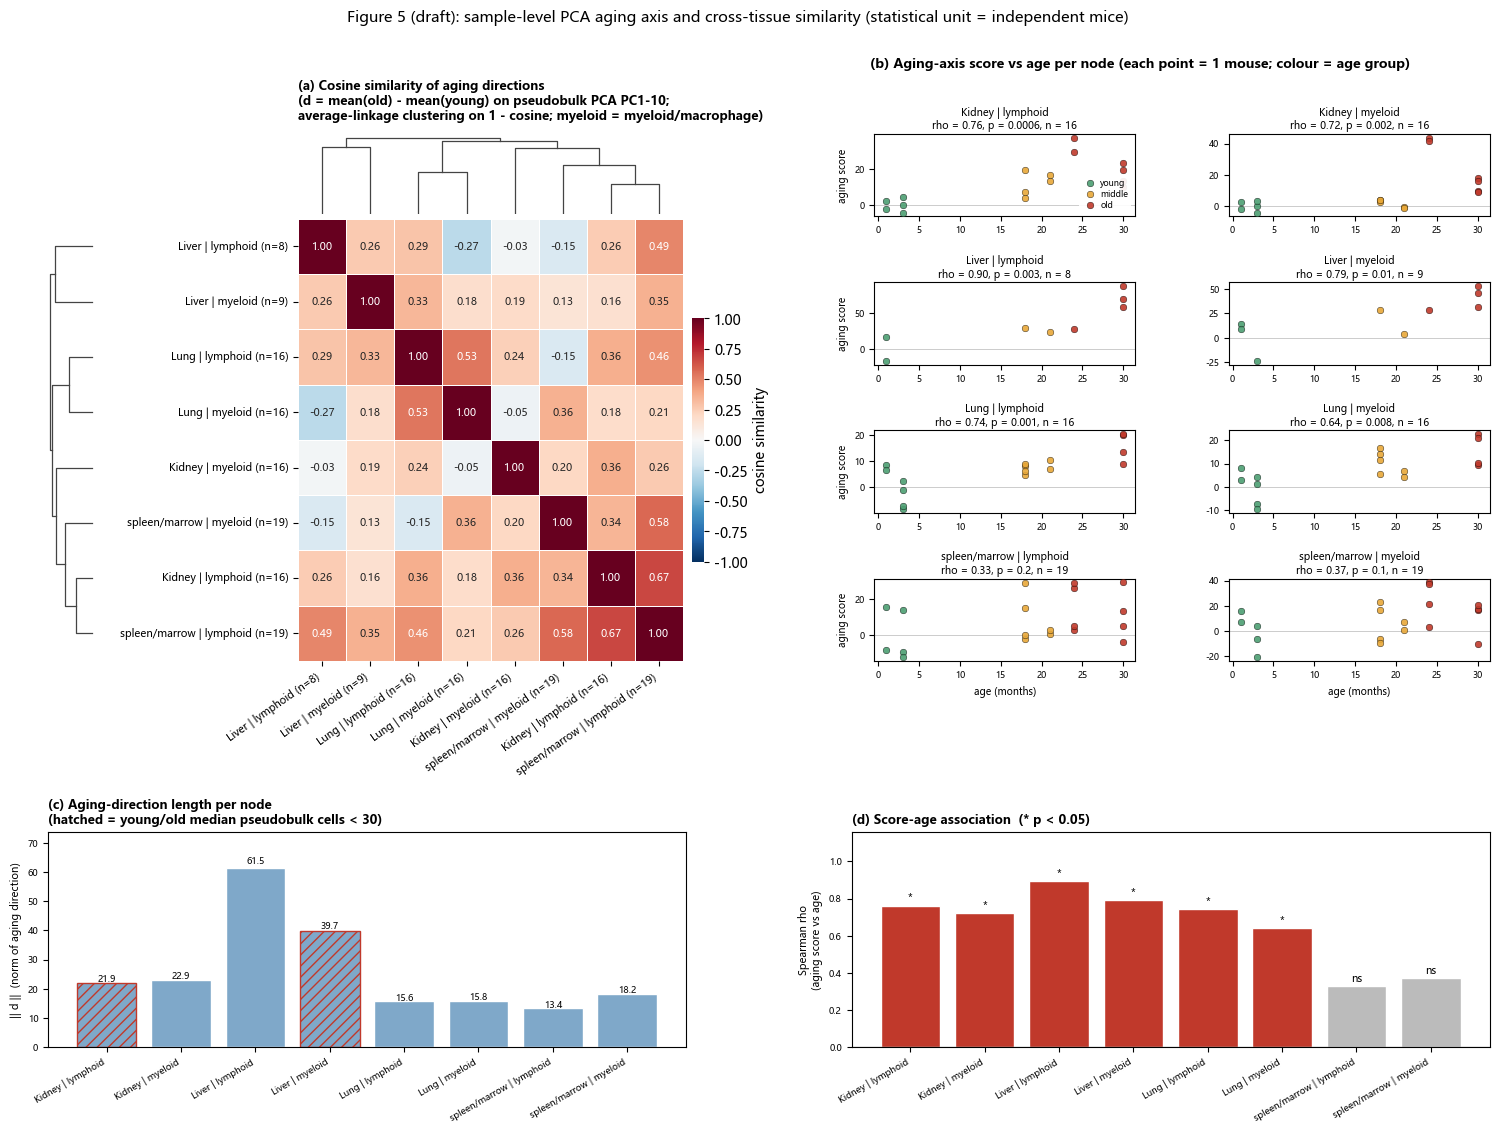

已保存 figures/main/Fig5_aging_similarity_draft.pdf / .png


In [8]:
# ===================== Cell 8：Fig5 主图（相似度热图 + 层次聚类 + 年龄趋势）=====================
AGE_COLORS = {"young": "#4C9F72", "middle": "#E8A838", "old": "#C0392B"}

def short_node(nd):
    """图内短标签：'tissue__celltype' -> 'tissue | celltype'，myeloid 简写。"""
    return nd.replace("__", " | ").replace("myeloid/macrophage", "myeloid")


def draw_dendro(Z, ax, orientation, n_leaves):
    """按热图数据坐标手动绘制树状图，保证与热图行列严格对齐。"""
    dd = dendrogram(Z, no_plot=True)
    maxd = max(max(d) for d in dd["dcoord"]) or 1.0
    for xs, ds in zip(dd["icoord"], dd["dcoord"]):
        # 叶位置 5,15,... -> 单元格中心 0.5,1.5,...
        xs = (np.asarray(xs, float) - 5.0) / 10.0 + 0.5
        ds = np.asarray(ds, float)
        if orientation == "top":
            ax.plot(xs, ds, color="#444444", lw=0.9)
        else:
            ax.plot(-ds, xs, color="#444444", lw=0.9)
    if orientation == "top":
        ax.set_xlim(0, n_leaves)
        ax.set_ylim(0, maxd * 1.05)
    else:
        ax.set_ylim(n_leaves, 0)
        ax.set_xlim(-maxd * 1.05, maxd * 0.05)
    ax.axis("off")


n_mice_lab = node_summary["n_mice_total"].to_dict()
cm = cos_mat.loc[order, order]
labels = [f"{short_node(c)} (n={n_mice_lab[c]})" for c in cm.columns]

fig = plt.figure(figsize=(15.5, 11.0))
outer = fig.add_gridspec(2, 2, left=0.055, right=0.985, top=0.885, bottom=0.055,
                         width_ratios=[1.16, 1.0], height_ratios=[2.45, 1.0],
                         hspace=0.46, wspace=0.17)

# ---------- (a) 相似度热图 + 行/列树状图 ----------
# 三列布局：[行树状图][行标签留白][热图]，与 clustermap 惯例一致，避免标签压住树
gb = outer[0, 0].subgridspec(2, 3, width_ratios=[0.10, 0.42, 1.0],
                             height_ratios=[0.18, 1], wspace=0.02, hspace=0.02)
ax_dl = fig.add_subplot(gb[1, 0])
ax_dt = fig.add_subplot(gb[0, 2])
ax_hm = fig.add_subplot(gb[1, 2])

sns.heatmap(cm, ax=ax_hm, cmap="RdBu_r", center=0.0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7.6},
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "cosine similarity", "shrink": 0.55, "pad": 0.02},
            xticklabels=labels, yticklabels=labels)
ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=35, ha="right", fontsize=7.6)
ax_hm.set_yticklabels(ax_hm.get_yticklabels(), rotation=0, fontsize=7.6)

draw_dendro(Z, ax_dt, "top", len(cm))
draw_dendro(Z, ax_dl, "left", len(cm))
ax_dt.set_xlim(ax_hm.get_xlim())
ax_dl.set_ylim(ax_hm.get_ylim())
# 标题画在树状图轴之上，避免压在树状图上
ax_dt.set_title("(a) Cosine similarity of aging directions\n"
                f"(d = mean(old) - mean(young) on pseudobulk PCA PC1-{N_PC_AXIS};\n"
                "average-linkage clustering on 1 - cosine; myeloid = myeloid/macrophage)",
                loc="left", fontsize=9, fontweight="bold", pad=10)

# ---------- (b) 各节点：衰老得分 vs 月龄（n = 独立小鼠）----------
gb2 = outer[0, 1].subgridspec(4, 2, hspace=0.80, wspace=0.36)
for i, nd in enumerate(VALID_NODES):
    ax = fig.add_subplot(gb2[i // 2, i % 2])
    sub = pca_scores[pca_scores["node"] == nd]
    for ag in ("young", "middle", "old"):
        g = sub[sub["age_group"] == ag]
        if len(g):
            ax.scatter(g["age_months"], g["aging_score"], s=23, alpha=0.9,
                       color=AGE_COLORS[ag], edgecolors="k", linewidths=0.3,
                       label=ag if i == 0 else None, zorder=3)
    rho = float(node_summary.loc[nd, "spearman_rho"])
    p = float(node_summary.loc[nd, "spearman_p"])
    n = int(node_summary.loc[nd, "n_mice_total"])
    ax.axhline(0, color="#CCCCCC", lw=0.7, zorder=0)
    ax.set_title(f"{short_node(nd)}\nrho = {rho:.2f}, p = {p:.1g}, n = {n}",
                 fontsize=7.3, pad=3.5)
    ax.tick_params(labelsize=6.3)
    if i == 0:
        # 第 1 格右下角在该节点为空区，放图例不遮点
        ax.legend(fontsize=6.0, loc="lower right", frameon=True, framealpha=0.92,
                  edgecolor="none", handletextpad=0.25, borderpad=0.3,
                  labelspacing=0.25)
    if i % 2 == 0:
        ax.set_ylabel("aging score", fontsize=7)
    if i >= len(VALID_NODES) - 2:
        ax.set_xlabel("age (months)", fontsize=7)
fig.text(0.585, 0.945, "(b) Aging-axis score vs age per node "
                       "(each point = 1 mouse; colour = age group)",
         fontsize=9.5, fontweight="bold", ha="left")

# ---------- (c)(d) 方向长度 与 年龄趋势 ----------
gb3 = outer[1, :].subgridspec(1, 2, wspace=0.26)
short = [short_node(nd) for nd in VALID_NODES]

ax = fig.add_subplot(gb3[0, 0])
dn = node_summary.loc[VALID_NODES, "direction_norm"]
bars = ax.bar(range(len(dn)), dn.values, color="#7FA8C9", edgecolor="white")
for b, nd in zip(bars, VALID_NODES):
    if nd in WEAK_NODES:                     # 证据较弱：young/old 中位细胞数 < 阈值
        b.set_hatch("///")
        b.set_edgecolor("#C0392B")
for i, v in enumerate(dn.values):
    ax.text(i, v * 1.02, f"{v:.1f}", ha="center", fontsize=6.6)
ax.set_xticks(range(len(dn)))
ax.set_xticklabels(short, rotation=30, ha="right", fontsize=6.6)
ax.set_ylabel("|| d ||  (norm of aging direction)", fontsize=7.5)
ax.set_ylim(0, dn.max() * 1.20)
ax.set_title(f"(c) Aging-direction length per node\n"
             f"(hatched = young/old median pseudobulk cells < {LOW_CELLS})",
             loc="left", fontsize=9, fontweight="bold")
ax.tick_params(axis="y", labelsize=6.6)

ax = fig.add_subplot(gb3[0, 1])
rr = node_summary.loc[VALID_NODES, "spearman_rho"]
pp = node_summary.loc[VALID_NODES, "spearman_p"]
ax.bar(range(len(rr)), rr.values,
       color=["#C0392B" if p < SIG_ALPHA else "#BBBBBB" for p in pp],
       edgecolor="white")
for i, (v, p) in enumerate(zip(rr.values, pp.values)):
    ax.text(i, v + 0.025, "*" if p < SIG_ALPHA else "ns", ha="center", fontsize=7.5)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(rr)))
ax.set_xticklabels(short, rotation=30, ha="right", fontsize=6.6)
ax.set_ylabel("Spearman rho\n(aging score vs age)", fontsize=7.5)
ax.set_ylim(0, 1.16)
ax.set_title(f"(d) Score-age association  (* p < {SIG_ALPHA})", loc="left",
             fontsize=9, fontweight="bold")
ax.tick_params(axis="y", labelsize=6.6)

# ---------- 对齐保险：树状图与热图的实际绘制区严格同步 ----------
fig.canvas.draw()
_p_hm = ax_hm.get_position()
_p_dt = ax_dt.get_position()
ax_dt.set_position([_p_hm.x0, _p_dt.y0, _p_hm.width, _p_dt.height])
_p_dl = ax_dl.get_position()
ax_dl.set_position([_p_dl.x0, _p_hm.y0, _p_dl.width, _p_hm.height])

fig.suptitle("Figure 5 (draft): sample-level PCA aging axis and cross-tissue similarity "
             "(statistical unit = independent mice)", y=0.998, fontsize=11)
fig.savefig(FIGDIR / "Fig5_aging_similarity_draft.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "Fig5_aging_similarity_draft.png", bbox_inches="tight", dpi=300)
plt.show()
print("已保存 figures/main/Fig5_aging_similarity_draft.pdf / .png")


In [9]:
# ===================== Cell 9：结果落盘与"分析前数据泄漏自检" =====================

n_mid = 0
for nd in VALID_NODES:
    sub = ml[ml["node"] == nd]
    _, _, _, n_y, n_o = aa.aging_direction(sub, PC_COLS)
    assert n_y + n_o == int(sub["age_group"].isin(["young", "old"]).sum()), \
        f"{nd}: 方向中心样本数与 young+old 不一致"
    n_mid += int((sub["age_group"] == "middle").sum())
print(f"1) 方向中心只由 young/old 估计：middle 小鼠累计 {n_mid} 头，"
      f"全部只参与投影，不参与 mu")

# 2) 投影按小鼠独立完成：每只小鼠在每节点恰 1 条样本，不做跨小鼠平均
g = ml.groupby(["node", "mouse.id"]).size()
assert g.max() == 1, "同一节点内同一小鼠出现多条样本"
print(f"2) 每节点每小鼠恰 1 条 pseudobulk 样本（最大重复数 = {int(g.max())}）"
      f"-> 投影独立，无跨小鼠平均")

# 3) LOSO 泄漏防护已实现在模块层，第11周据此运行
_demo, _, _, _, _ = aa.aging_direction(ml[ml["node"] == VALID_NODES[0]], PC_COLS,
                                      exclude_mice=[ml["mouse.id"].iloc[0]])
print("3) LOSO 接口自检通过：exclude_mice 可把被留出小鼠从中心估计中移除（第11周执行）")

# 4) 特征选择不使用年龄标签
print("4) HVG(seurat flavor) 仅依据表达量分位与表达-方差关系选基因，不涉及年龄标签")

audit = pd.DataFrame([
    {"check": "统计单位", "item": "n = 独立小鼠",
     "status": "pass", "evidence": "pseudobulk PCA 行 = mouse x tissue x cell_type，无重复"},
    {"check": "方向中心", "item": "mu 只由 young/old 估计",
     "status": "pass", "evidence": f"middle 小鼠 {n_mid} 头仅参与投影与年龄趋势"},
    {"check": "样本独立", "item": "投影不跨小鼠平均",
     "status": "pass", "evidence": "每节点每小鼠恰 1 条样本"},
    {"check": "样本坐标口径", "item": f"AGG_MODE = {AGG_MODE}",
     "status": "pass",
     "evidence": "pseudobulk PCA 下每节点每鼠恰 1 条坐标，均值即其本身"},
    {"check": "LOSO", "item": "留出的小鼠不参与中心估计",
     "status": "pass", "evidence": "aging_axis.aging_direction(exclude_mice=...)，第11周执行"},
    {"check": "特征选择", "item": "不使用测试标签选高变基因",
     "status": "pass", "evidence": "HVG 只用表达量分位，不涉及年龄标签"},
    {"check": "因果关系", "item": "相似性表述",
     "status": "n/a", "evidence": "余弦相似度只描述方向一致性，正文不得写成因果"},
])
audit.to_csv(AXIS / "leakage_audit.tsv", sep="\t", index=False)
print("\n泄漏自检表:")
print(audit.to_string(index=False))

# ---- 分析参数落盘（供论文"材料与方法"与可复现性章节直接引用）----
params = pd.DataFrame([
    {"parameter": "seed", "value": SEED},
    {"parameter": "n_pc_total", "value": N_PC_TOTAL},
    {"parameter": "n_pc_axis", "value": N_PC_AXIS},
    {"parameter": "agg_mode", "value": AGG_MODE},
    {"parameter": "min_young", "value": MIN_YOUNG},
    {"parameter": "min_old", "value": MIN_OLD},
    {"parameter": "sig_alpha", "value": SIG_ALPHA},
    {"parameter": "low_cells", "value": LOW_CELLS},
    {"parameter": "pca_input", "value": "data_processed/pseudobulk.h5ad (raw counts)"},
    {"parameter": "pca_pipeline",
     "value": "normalize_total(1e5) -> log1p -> scale(max_value=10) -> tl.pca(arpack)"},
    {"parameter": "n_nodes", "value": len(VALID_NODES)},
    {"parameter": "n_samples", "value": len(ml)},
    {"parameter": "n_mice", "value": int(ml["mouse.id"].nunique())},
])
params.to_csv(AXIS / "analysis_params.tsv", sep="\t", index=False)
print("\n已保存 -> results/aging_axis/analysis_params.tsv")

print("\n=== 第10周产出清单 ===")
for p in sorted(AXIS.glob("*")):
    print(f"  {p.relative_to(BASE)!s:52s} {p.stat().st_size:>8d} B")
for p in [FIGDIR / "Fig5_aging_similarity_draft.pdf",
          FIGDIR / "Fig5_aging_similarity_draft.png",
          BASE / "data_processed" / "pseudobulk_pca.h5ad"]:
    print(f"  {str(p.relative_to(BASE)):52s} {p.stat().st_size:>8d} B")
print("\n第10周（PCA 衰老方向与组织相似性）完成")


1) 方向中心只由 young/old 估计：middle 小鼠累计 38 头，全部只参与投影，不参与 mu
2) 每节点每小鼠恰 1 条 pseudobulk 样本（最大重复数 = 1）-> 投影独立，无跨小鼠平均
3) LOSO 接口自检通过：exclude_mice 可把被留出小鼠从中心估计中移除（第11周执行）
4) HVG(seurat flavor) 仅依据表达量分位与表达-方差关系选基因，不涉及年龄标签

泄漏自检表:
 check               item status                                            evidence
  统计单位           n = 独立小鼠   pass   pseudobulk PCA 行 = mouse x tissue x cell_type，无重复
  方向中心 mu 只由 young/old 估计   pass                            middle 小鼠 38 头仅参与投影与年龄趋势
  样本独立           投影不跨小鼠平均   pass                                       每节点每小鼠恰 1 条样本
样本坐标口径    AGG_MODE = mean   pass                 pseudobulk PCA 下每节点每鼠恰 1 条坐标，均值即其本身
  LOSO       留出的小鼠不参与中心估计   pass aging_axis.aging_direction(exclude_mice=...)，第11周执行
  特征选择       不使用测试标签选高变基因   pass                                 HVG 只用表达量分位，不涉及年龄标签
  因果关系              相似性表述    n/a                              余弦相似度只描述方向一致性，正文不得写成因果

已保存 -> results/aging_axis/analysis_params.tsv

=== 第10周产出清单 ===
  results\aging_axis\aging_direction